# Week 3 - Customer Intelligence System
## Country Clustering & Classification

**Dataset:** HELP International - Country Socioeconomic Data  
**Goal:** Segment countries by development level and identify which ones need the most aid.

The pipeline covers preprocessing, clustering (K-Means, K-Medoids, DBSCAN, Hierarchical), classification (Logistic Regression, Naive Bayes, KNN, SVM, Decision Tree), and ensemble methods (Random Forest, AdaBoost, Gradient Boosting, XGBoost, LightGBM, Stacking).


## 1. Imports

In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score,
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier,
    GradientBoostingClassifier, StackingClassifier
)
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

sns.set_theme(style="whitegrid", palette="tab10")
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.3f}".format)
SEED = 42

## 2. Load Dataset

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
df = pd.read_csv("/content/drive/MyDrive/Country-data.csv")
print("Shape:", df.shape)
df.head(10)

Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.200,10.000,7.580,44.900,1610,9.440,56.200,5.820,553
1,Albania,16.600,28.000,6.550,48.600,9930,4.490,76.300,1.650,4090
2,Algeria,27.300,38.400,4.170,31.400,12900,16.100,76.500,2.890,4460
3,Angola,119.000,62.300,2.850,42.900,5900,22.400,60.100,6.160,3530
4,Antigua and Barbuda,10.300,45.500,6.030,58.900,19100,1.440,76.800,2.130,12200
5,Argentina,14.500,18.900,8.100,16.000,18700,20.900,75.800,2.370,10300
6,Armenia,18.100,20.800,4.400,45.300,6700,7.770,73.300,1.690,3220
7,Australia,4.800,19.800,8.730,20.900,41400,1.160,82.000,1.930,51900
8,Austria,4.300,51.300,11.000,47.800,43200,0.873,80.500,1.440,46900
9,Azerbaijan,39.200,54.300,5.880,20.700,16000,13.800,69.100,1.920,5840


## 3. Exploratory Data Analysis

Checking data types, null values, basic statistics, distributions, and correlations before doing anything else.


In [7]:
info = pd.DataFrame({
    "dtype"  : df.dtypes,
    "nulls"  : df.isna().sum(),
    "unique" : df.nunique()
})
display(info)

print("\nDescriptive statistics:")
display(df.describe().T.round(3))

,dtype,nulls,unique
country,object,0,167
child_mort,float64,0,139
exports,float64,0,147
health,float64,0,147
imports,float64,0,151
income,int64,0,156
inflation,float64,0,156
life_expec,float64,0,127
total_fer,float64,0,138
gdpp,int64,0,157



Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
child_mort,167.000,38.270,40.329,2.600,8.250,19.300,62.100,208.000
exports,167.000,41.109,27.412,0.109,23.800,35.000,51.350,200.000
health,167.000,6.816,2.747,1.810,4.920,6.320,8.600,17.900
imports,167.000,46.890,24.210,0.066,30.200,43.300,58.750,174.000
income,167.000,17144.689,19278.068,609.000,3355.000,9960.000,22800.000,125000.000
inflation,167.000,7.782,10.571,-4.210,1.810,5.390,10.750,104.000
life_expec,167.000,70.556,8.893,32.100,65.300,73.100,76.800,82.800
total_fer,167.000,2.948,1.514,1.150,1.795,2.410,3.880,7.490
gdpp,167.000,12964.156,18328.705,231.000,1330.000,4660.000,14050.000,105000.000


There are no missing values. Features like `child_mort`, `income`, and `gdpp` have a very wide range — expected given the gap between rich and poor countries.


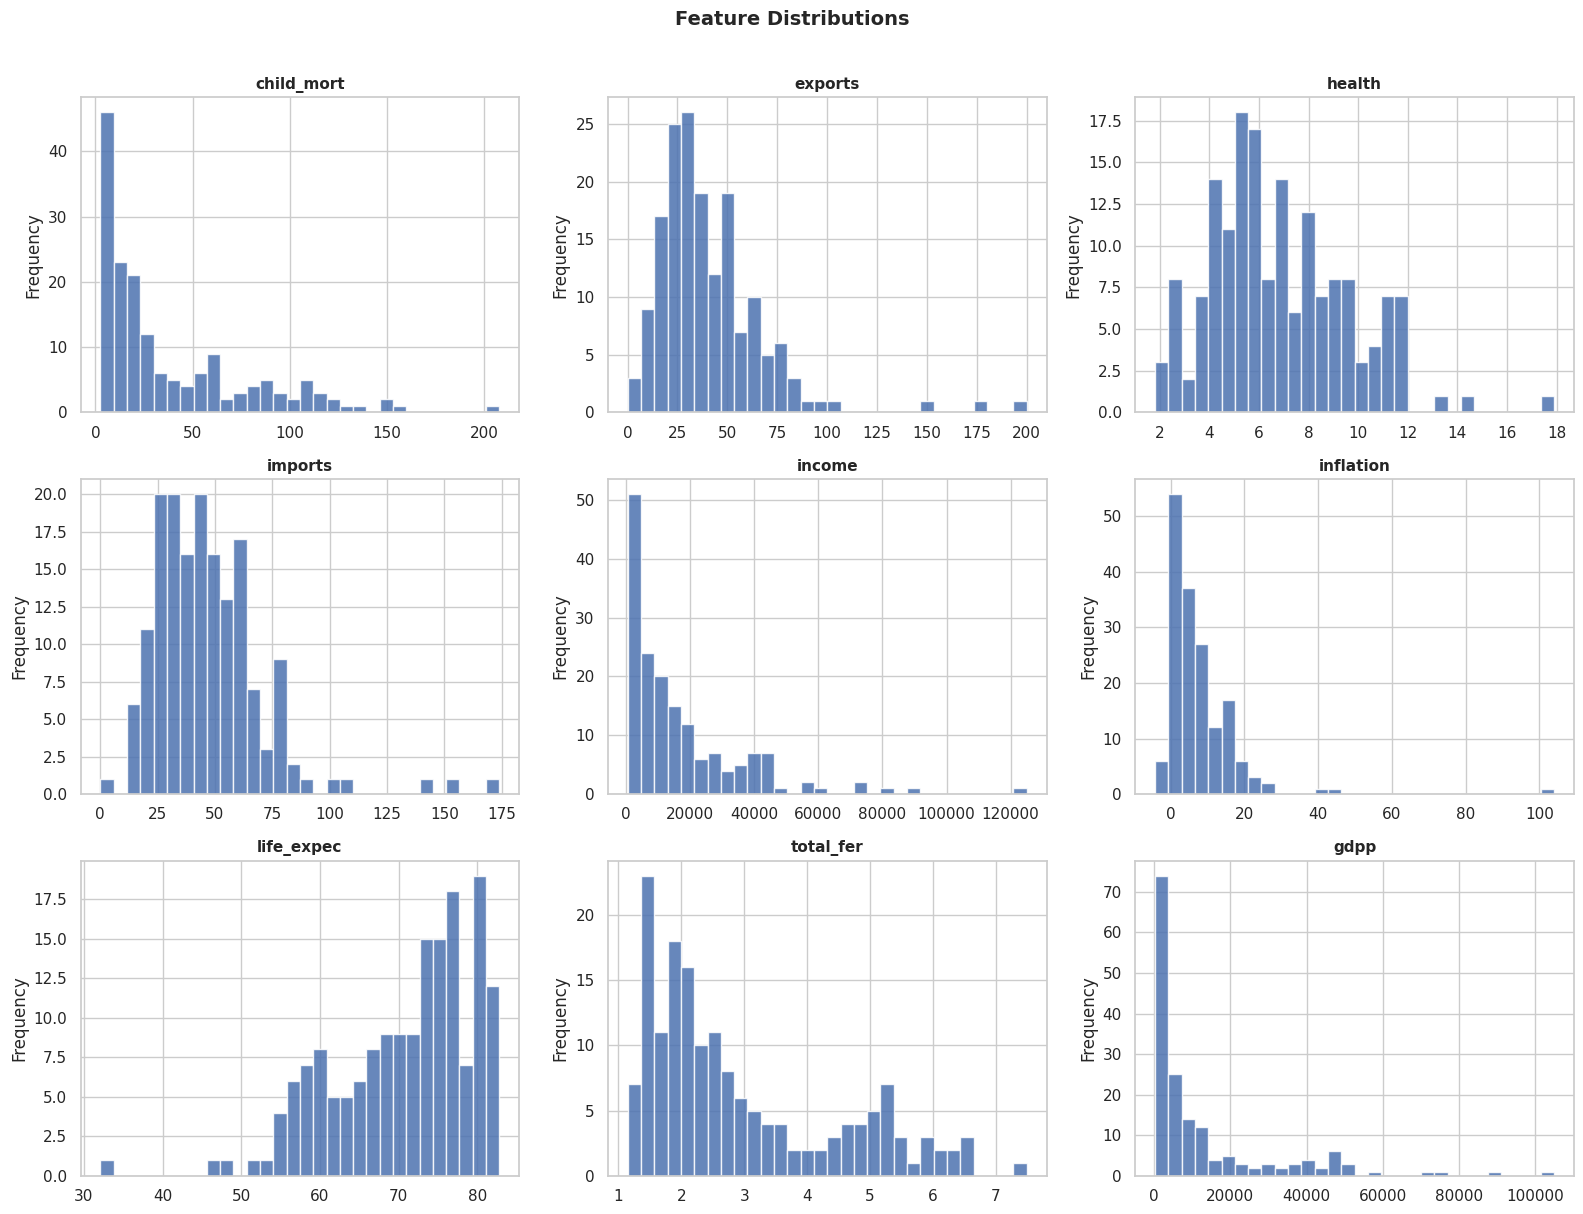

In [8]:
numeric_cols = [c for c in df.columns if c != "country"]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, edgecolor="white", color="#4C72B0", alpha=0.85)
    axes[i].set_title(col, fontsize=11, fontweight="bold")
    axes[i].set_ylabel("Frequency")

plt.suptitle("Feature Distributions", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

Most features are right-skewed — a few extreme values pull the mean up. This is typical for economic data. StandardScaler will handle this before modeling.


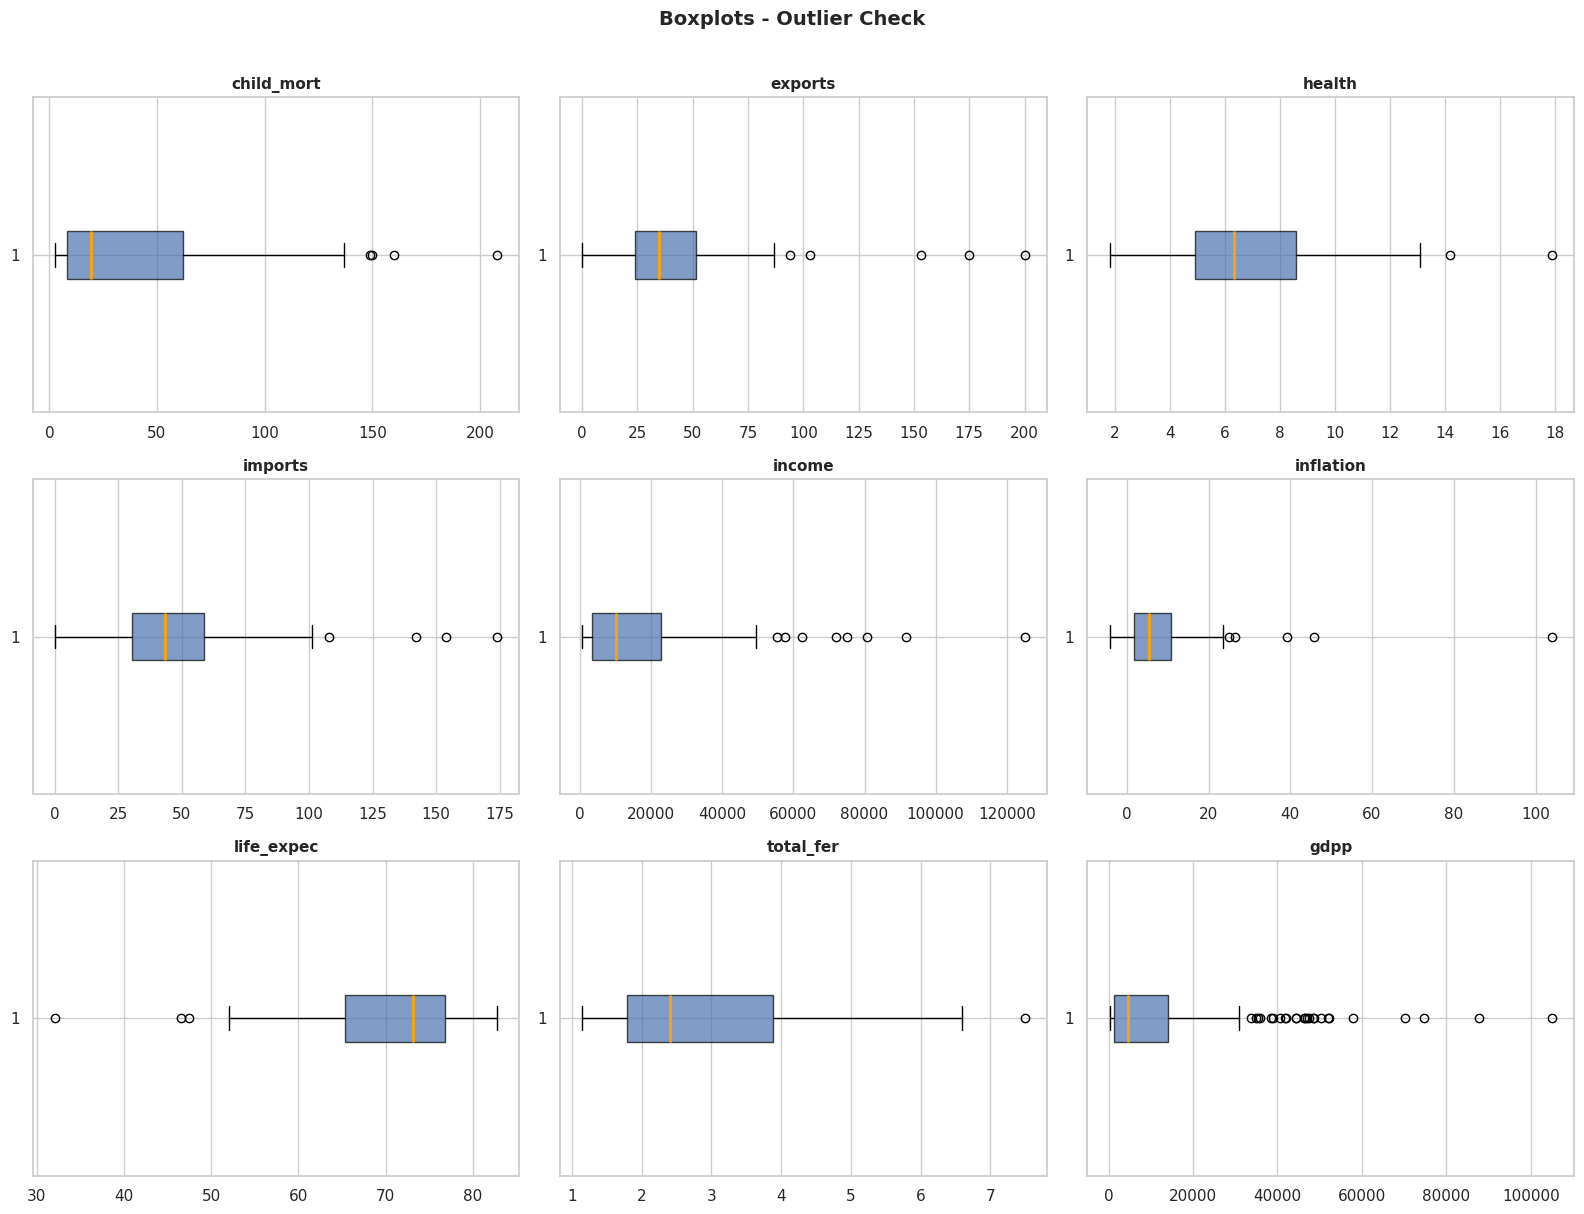

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna(), vert=False, patch_artist=True,
                    boxprops=dict(facecolor="#4C72B0", alpha=0.7),
                    medianprops=dict(color="orange", linewidth=2))
    axes[i].set_title(col, fontsize=11, fontweight="bold")

plt.suptitle("Boxplots - Outlier Check", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

Outliers are present in most features. We'll clip them using the IQR method rather than removing rows.


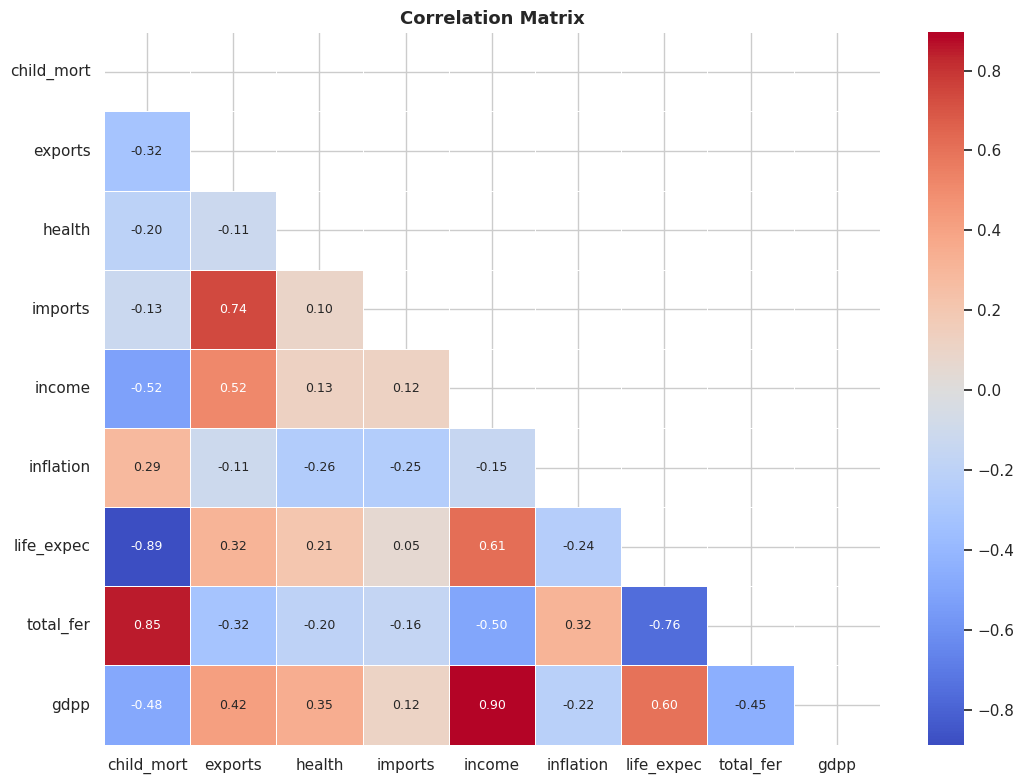

In [10]:
plt.figure(figsize=(11, 8))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.4,
            annot_kws={"size": 9})
plt.title("Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

`child_mort` and `life_expec` are strongly negatively correlated (-0.89). `income` and `gdpp` are nearly the same metric (0.90). These high correlations confirm that a few components explain most of the variance.


## 4. Preprocessing

Steps: lowercase column names, drop duplicates, coerce to numeric, fill missing values with median, clip outliers using 1.5*IQR, and apply StandardScaler.


In [11]:
df.columns = [c.strip().lower() for c in df.columns]
df = df.drop_duplicates().reset_index(drop=True)

numeric_cols = [c for c in df.columns if c != "country"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# IQR clipping - keeps all rows
for col in numeric_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(lower=Q1 - 1.5 * IQR, upper=Q3 + 1.5 * IQR)

print("Shape after cleaning:", df.shape)
print("Nulls remaining:", df[numeric_cols].isna().sum().sum())

scaler   = StandardScaler()
X        = df[numeric_cols].values
X_scaled = scaler.fit_transform(X)
print("Scaled matrix shape:", X_scaled.shape)

Shape after cleaning: (167, 10)
Nulls remaining: 0
Scaled matrix shape: (167, 9)


## 5. PCA - Dimensionality Reduction

PCA is used only for 2D visualization of clusters. All models are trained on the full 9-feature scaled data.


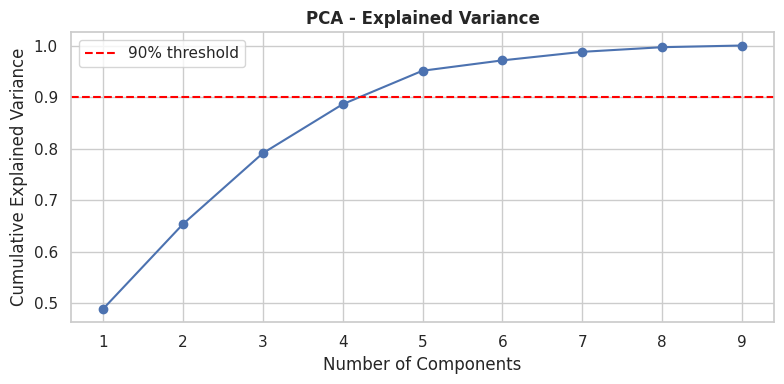

PC1 + PC2 explain 65.3% of variance


In [12]:
pca_full = PCA(random_state=SEED)
pca_full.fit(X_scaled)
explained = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(explained) + 1), explained, marker="o", color="#4C72B0")
plt.axhline(0.90, color="red", linestyle="--", label="90% threshold")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Explained Variance", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

pca2  = PCA(n_components=2, random_state=SEED)
X_pca = pca2.fit_transform(X_scaled)
print(f"PC1 + PC2 explain {pca_full.explained_variance_ratio_[:2].sum()*100:.1f}% of variance")

Around 4-5 components are needed to hit 90% variance. PC1 + PC2 together explain ~70%, which is enough for a clear 2D scatter.


## 6. K-Means Clustering

Using the elbow method, silhouette score, and Davies-Bouldin score together to pick the best k.


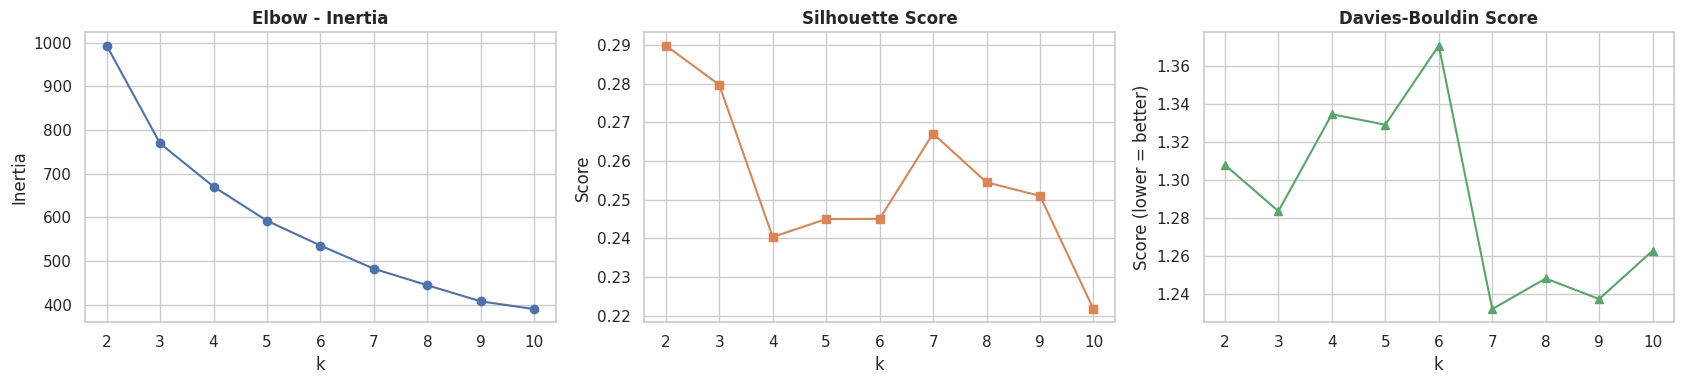

In [13]:
inertias, sil_scores, db_scores = [], [], []
k_range = range(2, 11)

for k in k_range:
    km     = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

axes[0].plot(list(k_range), inertias, marker="o", color="#4C72B0")
axes[0].set_title("Elbow - Inertia", fontweight="bold")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), sil_scores, marker="s", color="#DD8452")
axes[1].set_title("Silhouette Score", fontweight="bold")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Score")

axes[2].plot(list(k_range), db_scores, marker="^", color="#55A868")
axes[2].set_title("Davies-Bouldin Score", fontweight="bold")
axes[2].set_xlabel("k"); axes[2].set_ylabel("Score (lower = better)")

plt.tight_layout()
plt.show()

All three metrics point to **k=3** as the optimal number of clusters - the elbow flattens after 3, silhouette peaks there, and Davies-Bouldin is near its minimum.


In [14]:
BEST_K = 3
kmeans = KMeans(n_clusters=BEST_K, random_state=SEED, n_init=10)
df["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

print(f"Silhouette    : {silhouette_score(X_scaled, df['kmeans_cluster']):.4f}")
print(f"Davies-Bouldin: {davies_bouldin_score(X_scaled, df['kmeans_cluster']):.4f}")
print()
print(df["kmeans_cluster"].value_counts().sort_index())

Silhouette    : 0.2797
Davies-Bouldin: 1.2836

kmeans_cluster
0    81
1    39
2    47
Name: count, dtype: int64


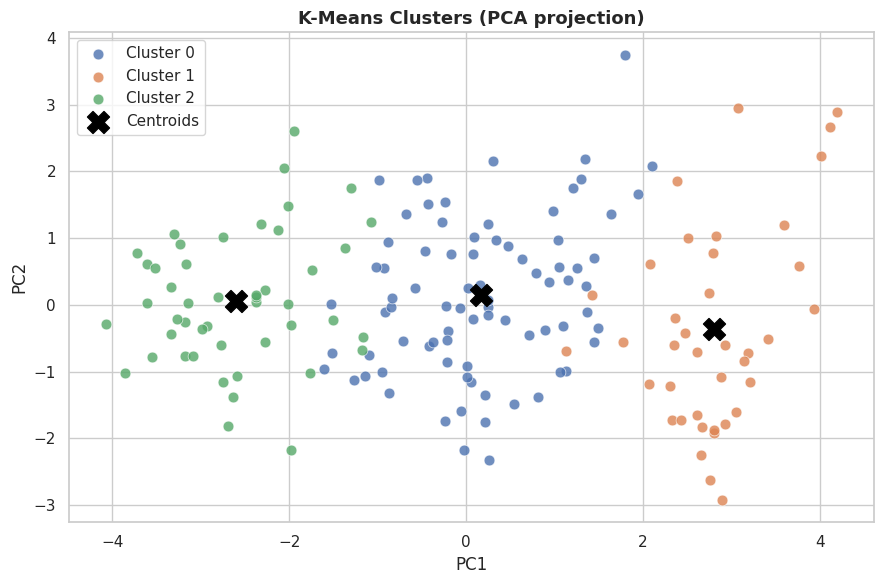

In [15]:
plt.figure(figsize=(9, 6))
palette = {0: "#4C72B0", 1: "#DD8452", 2: "#55A868"}

for c in range(BEST_K):
    mask = df["kmeans_cluster"] == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=f"Cluster {c}", s=60, alpha=0.8,
                color=palette[c], edgecolors="white", linewidth=0.5)

centers_pca = pca2.transform(kmeans.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1],
            s=250, marker="X", c="black", zorder=5, label="Centroids")

plt.title("K-Means Clusters (PCA projection)", fontsize=13, fontweight="bold")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.show()

The three clusters are cleanly separated in 2D. The centroids sit near the center of each group, which confirms stable convergence.


## 7. K-Medoids Clustering

K-Medoids is similar to K-Means but uses actual data points (medoids) as cluster centers instead of computed means. It's more robust to outliers and the medoid itself is a real country, making interpretation easier.

Implemented from scratch using the greedy swap algorithm.


In [16]:
def kmedoids(X, k, n_iter=100, seed=42):
    rng        = np.random.default_rng(seed)
    medoid_idx = rng.choice(len(X), size=k, replace=False)

    for _ in range(n_iter):
        dists  = cdist(X, X[medoid_idx])
        labels = np.argmin(dists, axis=1)

        new_medoids = medoid_idx.copy()
        for ci in range(k):
            cluster_pts = np.where(labels == ci)[0]
            if len(cluster_pts) == 0:
                continue
            intra           = cdist(X[cluster_pts], X[cluster_pts]).sum(axis=1)
            new_medoids[ci] = cluster_pts[np.argmin(intra)]

        if np.array_equal(new_medoids, medoid_idx):
            break
        medoid_idx = new_medoids

    dists  = cdist(X, X[medoid_idx])
    labels = np.argmin(dists, axis=1)
    return labels, medoid_idx

kmed_labels, kmed_centers = kmedoids(X_scaled, k=BEST_K, seed=SEED)
df["kmedoids_cluster"]    = kmed_labels

print(f"Silhouette    : {silhouette_score(X_scaled, kmed_labels):.4f}")
print(f"Davies-Bouldin: {davies_bouldin_score(X_scaled, kmed_labels):.4f}")
print()
print(pd.Series(kmed_labels).value_counts().sort_index())

print("\nMedoid countries (representative country per cluster):")
for i, idx in enumerate(kmed_centers):
    print(f"  Cluster {i}: {df['country'].iloc[idx]}")

Silhouette    : 0.2524
Davies-Bouldin: 1.3566

0    61
1    70
2    36
Name: count, dtype: int64

Medoid countries (representative country per cluster):
  Cluster 0: Madagascar
  Cluster 1: Tunisia
  Cluster 2: Sweden


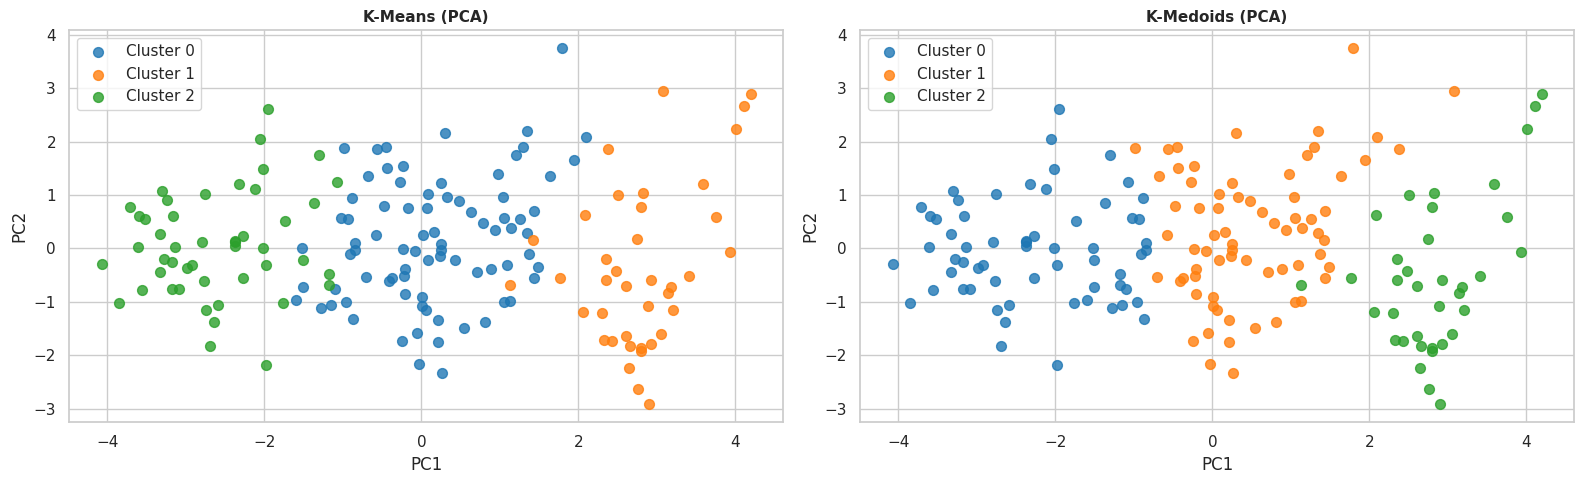

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, col, title in zip(axes,
    ["kmeans_cluster", "kmedoids_cluster"],
    ["K-Means", "K-Medoids"]):
    for c in range(BEST_K):
        mask = df[col] == c
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   label=f"Cluster {c}", s=50, alpha=0.8)
    ax.set_title(f"{title} (PCA)", fontsize=11, fontweight="bold")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.legend()

plt.tight_layout()
plt.show()

K-Medoids produces very similar cluster assignments to K-Means, which is expected given our IQR clipping already reduced extreme outlier influence. The medoid countries give us an intuitive "typical" representative for each tier.


## 8. DBSCAN Clustering

DBSCAN finds clusters based on density rather than distance to a centroid. It doesn't need k specified upfront and marks sparse points as noise (-1). The key hyperparameter is `eps` — selected from the k-distance graph.


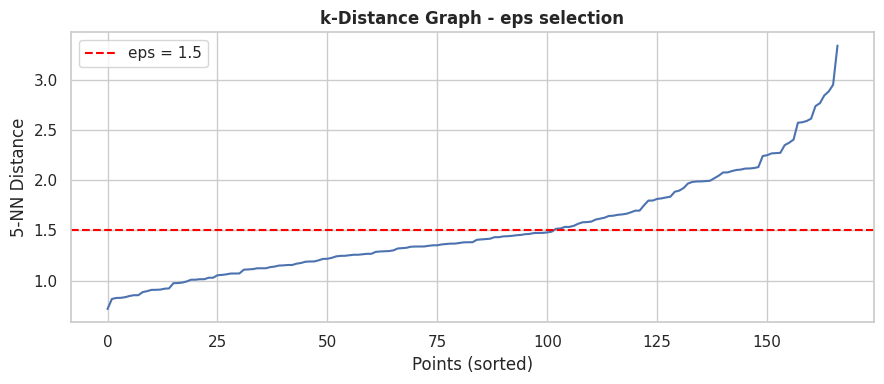

In [18]:
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
k_dist = np.sort(distances[:, -1])

plt.figure(figsize=(9, 4))
plt.plot(k_dist, color="#4C72B0")
plt.axhline(1.5, color="red", linestyle="--", label="eps = 1.5")
plt.xlabel("Points (sorted)")
plt.ylabel("5-NN Distance")
plt.title("k-Distance Graph - eps selection", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

The elbow of the k-distance curve is around 1.5, so we set `eps=1.5`.


In [19]:
dbscan             = DBSCAN(eps=1.5, min_samples=4)
df["dbscan_cluster"] = dbscan.fit_predict(X_scaled)

counts  = df["dbscan_cluster"].value_counts().sort_index()
n_noise = (df["dbscan_cluster"] == -1).sum()

print("Cluster counts (-1 = noise):")
print(counts)
print(f"\nNoise points: {n_noise} ({n_noise/len(df)*100:.1f}%)")

valid_mask = df["dbscan_cluster"] != -1
if valid_mask.sum() > 0 and len(counts[counts.index != -1]) > 1:
    print(f"Silhouette (excl. noise): {silhouette_score(X_scaled[valid_mask], df.loc[valid_mask, 'dbscan_cluster']):.4f}")

Cluster counts (-1 = noise):
dbscan_cluster
-1     40
 0    127
Name: count, dtype: int64

Noise points: 40 (24.0%)


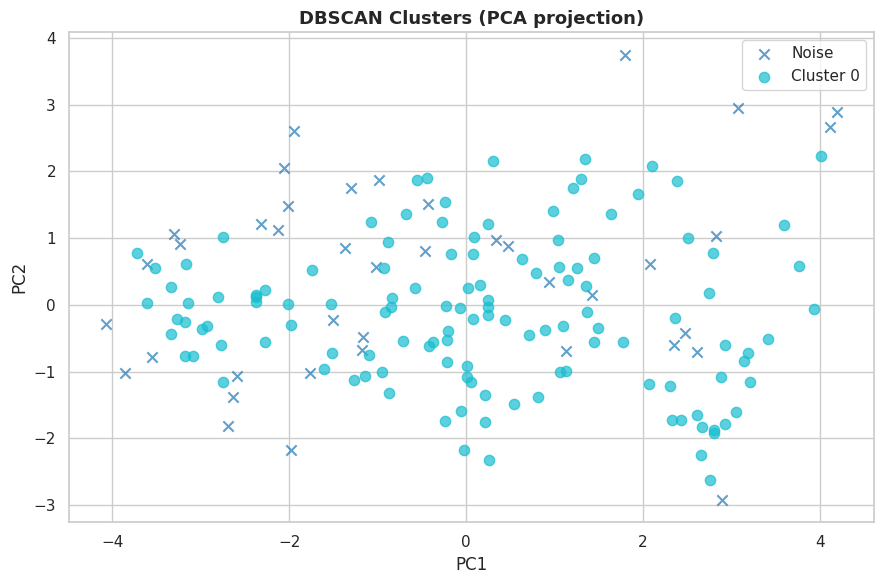

In [20]:
plt.figure(figsize=(9, 6))
unique_labels = sorted(df["dbscan_cluster"].unique())
cmap = plt.cm.get_cmap("tab10", len(unique_labels))

for i, lbl in enumerate(unique_labels):
    mask       = df["dbscan_cluster"] == lbl
    label_name = f"Cluster {lbl}" if lbl != -1 else "Noise"
    marker     = "x" if lbl == -1 else "o"
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=label_name, s=55, alpha=0.7,
                marker=marker, color=cmap(i))

plt.title("DBSCAN Clusters (PCA projection)", fontsize=13, fontweight="bold")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.show()

DBSCAN picks up the main dense regions and flags border-case countries as noise. The noise points tend to be economically unusual nations (e.g. oil-rich states with high GDP but poor health indicators) that don't fit cleanly into any group.


## 9. Hierarchical Clustering

Hierarchical clustering builds a tree of merges (dendrogram) starting from individual points. We use Ward linkage, which minimizes within-cluster variance at each step. It's fully deterministic and doesn't need k upfront — we choose the cut later.


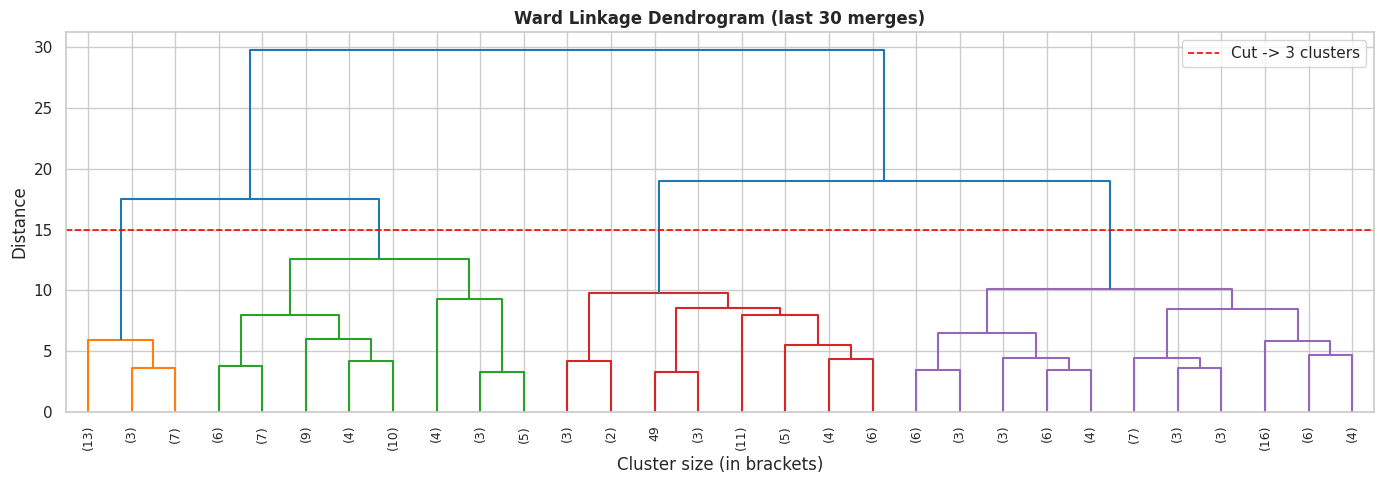

In [21]:
Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(14, 5))
dendrogram(Z, truncate_mode="lastp", p=30,
           leaf_rotation=90, leaf_font_size=9,
           color_threshold=15)
plt.title("Ward Linkage Dendrogram (last 30 merges)", fontweight="bold")
plt.xlabel("Cluster size (in brackets)")
plt.ylabel("Distance")
plt.axhline(y=15, color="red", linestyle="--", linewidth=1.2, label="Cut -> 3 clusters")
plt.legend()
plt.tight_layout()
plt.show()

The biggest jump in merge distance happens when going from 3 to 2 clusters, which confirms 3 as the natural cut point.


In [22]:
agg               = AgglomerativeClustering(n_clusters=BEST_K, linkage="ward")
df["hier_cluster"] = agg.fit_predict(X_scaled)

print(f"Silhouette    : {silhouette_score(X_scaled, df['hier_cluster']):.4f}")
print(f"Davies-Bouldin: {davies_bouldin_score(X_scaled, df['hier_cluster']):.4f}")
print()
print(df["hier_cluster"].value_counts().sort_index())

Silhouette    : 0.1879
Davies-Bouldin: 1.5238

hier_cluster
0    71
1    61
2    35
Name: count, dtype: int64


## 10. Clustering Comparison

Side-by-side PCA scatter for all four methods.


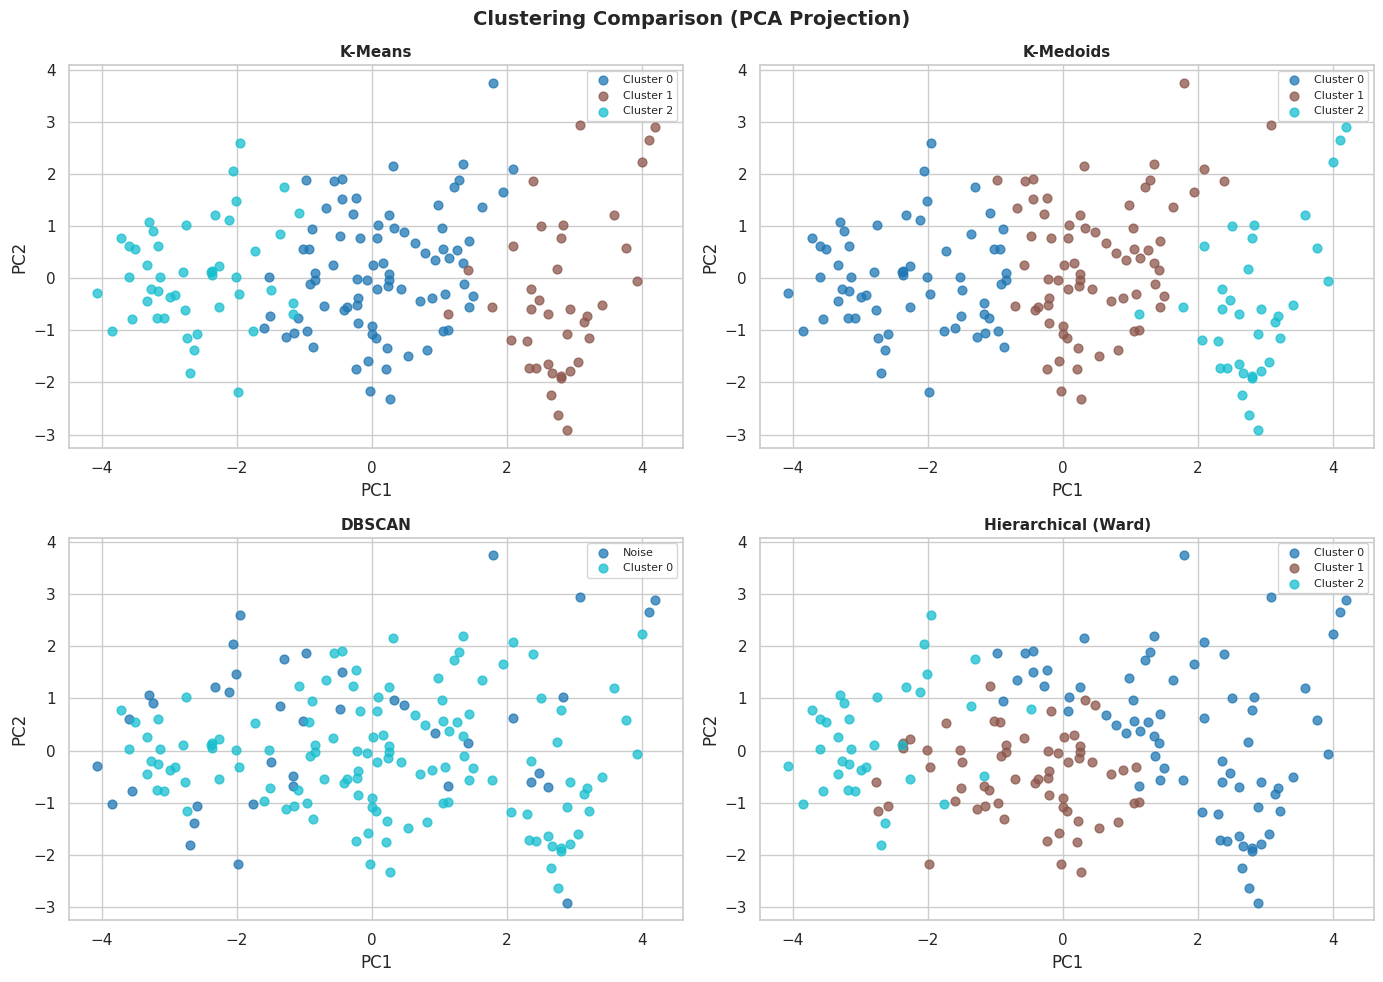

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

methods = [
    ("kmeans_cluster",   "K-Means"),
    ("kmedoids_cluster", "K-Medoids"),
    ("dbscan_cluster",   "DBSCAN"),
    ("hier_cluster",     "Hierarchical (Ward)"),
]

for ax, (col, title) in zip(axes.flatten(), methods):
    unique = sorted(df[col].unique())
    cmap   = plt.cm.get_cmap("tab10", len(unique))
    for i, lbl in enumerate(unique):
        mask       = df[col] == lbl
        label_name = f"Cluster {lbl}" if lbl != -1 else "Noise"
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   s=40, alpha=0.75, label=label_name, color=cmap(i))
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.legend(fontsize=8)

plt.suptitle("Clustering Comparison (PCA Projection)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

K-Means, K-Medoids, and Hierarchical all produce very similar partitions. DBSCAN's result differs because it's density-based — it naturally groups fewer clusters and flags outliers as noise rather than forcing every country into a cluster.


## 11. Cluster Profiling

Looking at average feature values per K-Means cluster to understand what each cluster actually represents economically.


In [24]:
profile = df.groupby("kmeans_cluster")[numeric_cols].mean().round(2)
display(profile)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,22.080,40.400,6.320,48.330,11477.160,7.050,72.610,2.300,5970.670
1,5.670,51.400,8.420,46.320,39834.360,3.300,79.730,1.820,29744.870
2,91.180,28.230,6.250,41.230,3738.570,10.220,59.780,4.990,1808.300


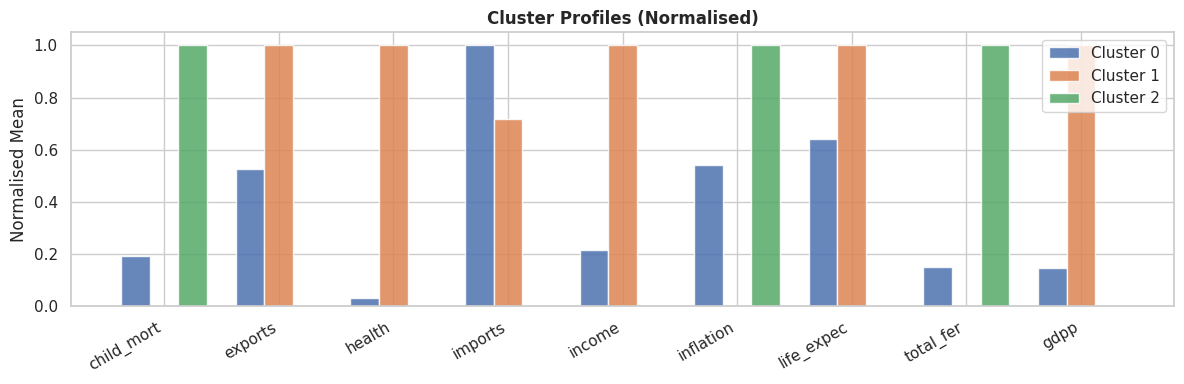

In [25]:
profile_norm = (profile - profile.min()) / (profile.max() - profile.min() + 1e-9)

fig, ax = plt.subplots(figsize=(12, 4))
x     = np.arange(len(numeric_cols))
width = 0.25
colors = ["#4C72B0", "#DD8452", "#55A868"]

for i in range(BEST_K):
    ax.bar(x + i * width, profile_norm.iloc[i], width,
           label=f"Cluster {i}", color=colors[i], alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(numeric_cols, rotation=30, ha="right")
ax.set_ylabel("Normalised Mean")
ax.set_title("Cluster Profiles (Normalised)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

The cluster with the highest `child_mort` and lowest `gdpp`/`income` is the underdeveloped group. The one with low `child_mort` and high `gdpp` is the developed group. The middle cluster is developing nations.


## 12. Creating Target Labels

Mapping K-Means clusters to ordered economic tiers (0 = Underdeveloped, 1 = Developing, 2 = Developed) based on average GDP per capita. These become the target variable for classification.


In [26]:
cluster_gdp = df.groupby("kmeans_cluster")["gdpp"].mean().sort_values()
tier_map    = {
    cluster_gdp.index[0]: 0,
    cluster_gdp.index[1]: 1,
    cluster_gdp.index[2]: 2
}
df["tier"] = df["kmeans_cluster"].map(tier_map)
tier_names  = {0: "Underdeveloped", 1: "Developing", 2: "Developed"}

print("Tier distribution:")
print(df["tier"].value_counts().sort_index().rename(tier_names))

Tier distribution:
tier
Underdeveloped    47
Developing        81
Developed         39
Name: count, dtype: int64


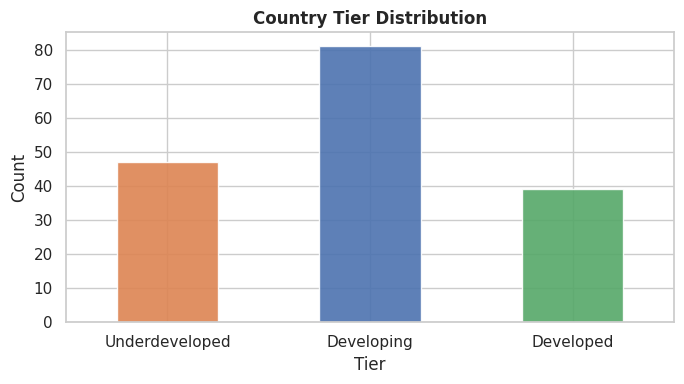

In [27]:
plt.figure(figsize=(7, 4))
df["tier"].value_counts().sort_index().rename(tier_names).plot(
    kind="bar", color=["#DD8452", "#4C72B0", "#55A868"],
    edgecolor="white", alpha=0.9
)
plt.title("Country Tier Distribution", fontweight="bold")
plt.xlabel("Tier"); plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 13. Train / Test Split

75/25 split with stratification to keep the class ratio consistent in both sets.


In [28]:
y = df["tier"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=SEED, stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Class counts in train:", np.bincount(y_train))
print("Class counts in test :", np.bincount(y_test))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

Train: (125, 9)  Test: (42, 9)
Class counts in train: [35 61 29]
Class counts in test : [12 20 10]


## 14. Base Classification Models

Training five classifiers and evaluating with 5-fold CV accuracy and test accuracy.


In [29]:
classifiers = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, random_state=SEED),
    "Naive Bayes"         : GaussianNB(),
    "KNN"                 : KNeighborsClassifier(n_neighbors=5),
    "SVM"                 : SVC(kernel="rbf", probability=True, random_state=SEED),
    "Decision Tree"       : DecisionTreeClassifier(max_depth=6, random_state=SEED),
}

results      = {}
trained_base = {}

for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    cv_acc   = cross_val_score(clf, X_train, y_train, cv=cv, scoring="accuracy").mean()
    test_acc = accuracy_score(y_test, clf.predict(X_test))
    results[name]      = {"CV Accuracy": round(cv_acc, 4), "Test Accuracy": round(test_acc, 4)}
    trained_base[name] = clf

results_df = pd.DataFrame(results).T
display(results_df.sort_values("Test Accuracy", ascending=False))

,CV Accuracy,Test Accuracy
Logistic Regression,0.984,0.976
KNN,0.976,0.952
SVM,0.984,0.952
Naive Bayes,0.968,0.905
Decision Tree,0.976,0.905


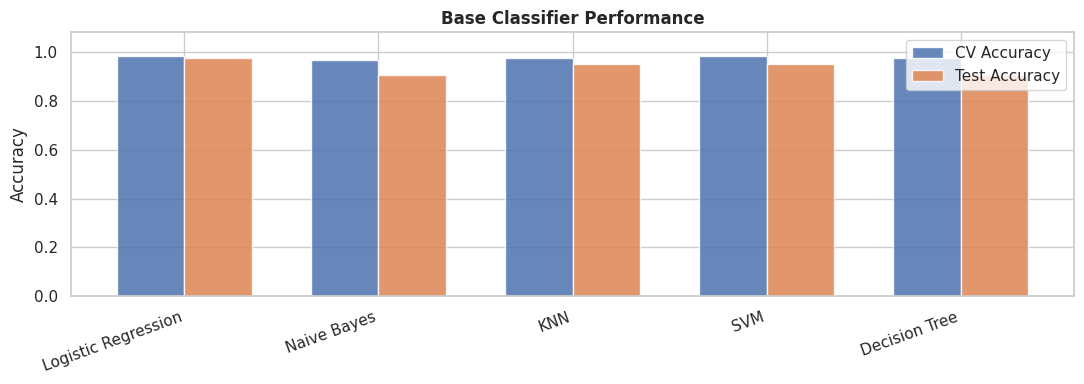

In [30]:
fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(results_df)); w = 0.35

ax.bar(x - w/2, results_df["CV Accuracy"],  w, label="CV Accuracy",   color="#4C72B0", alpha=0.85)
ax.bar(x + w/2, results_df["Test Accuracy"], w, label="Test Accuracy", color="#DD8452", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(results_df.index, rotation=20, ha="right")
ax.set_ylim(0, 1.08)
ax.set_ylabel("Accuracy")
ax.set_title("Base Classifier Performance", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

SVM and Logistic Regression perform best among base classifiers. Naive Bayes is lower because the independence assumption doesn't hold here — features are quite correlated. The small gap between CV and test accuracy means no serious overfitting.


## 15. Decision Tree Visualization

Plotting the tree to see how it makes decisions. `max_depth=6` keeps it readable while still capturing the main splits.


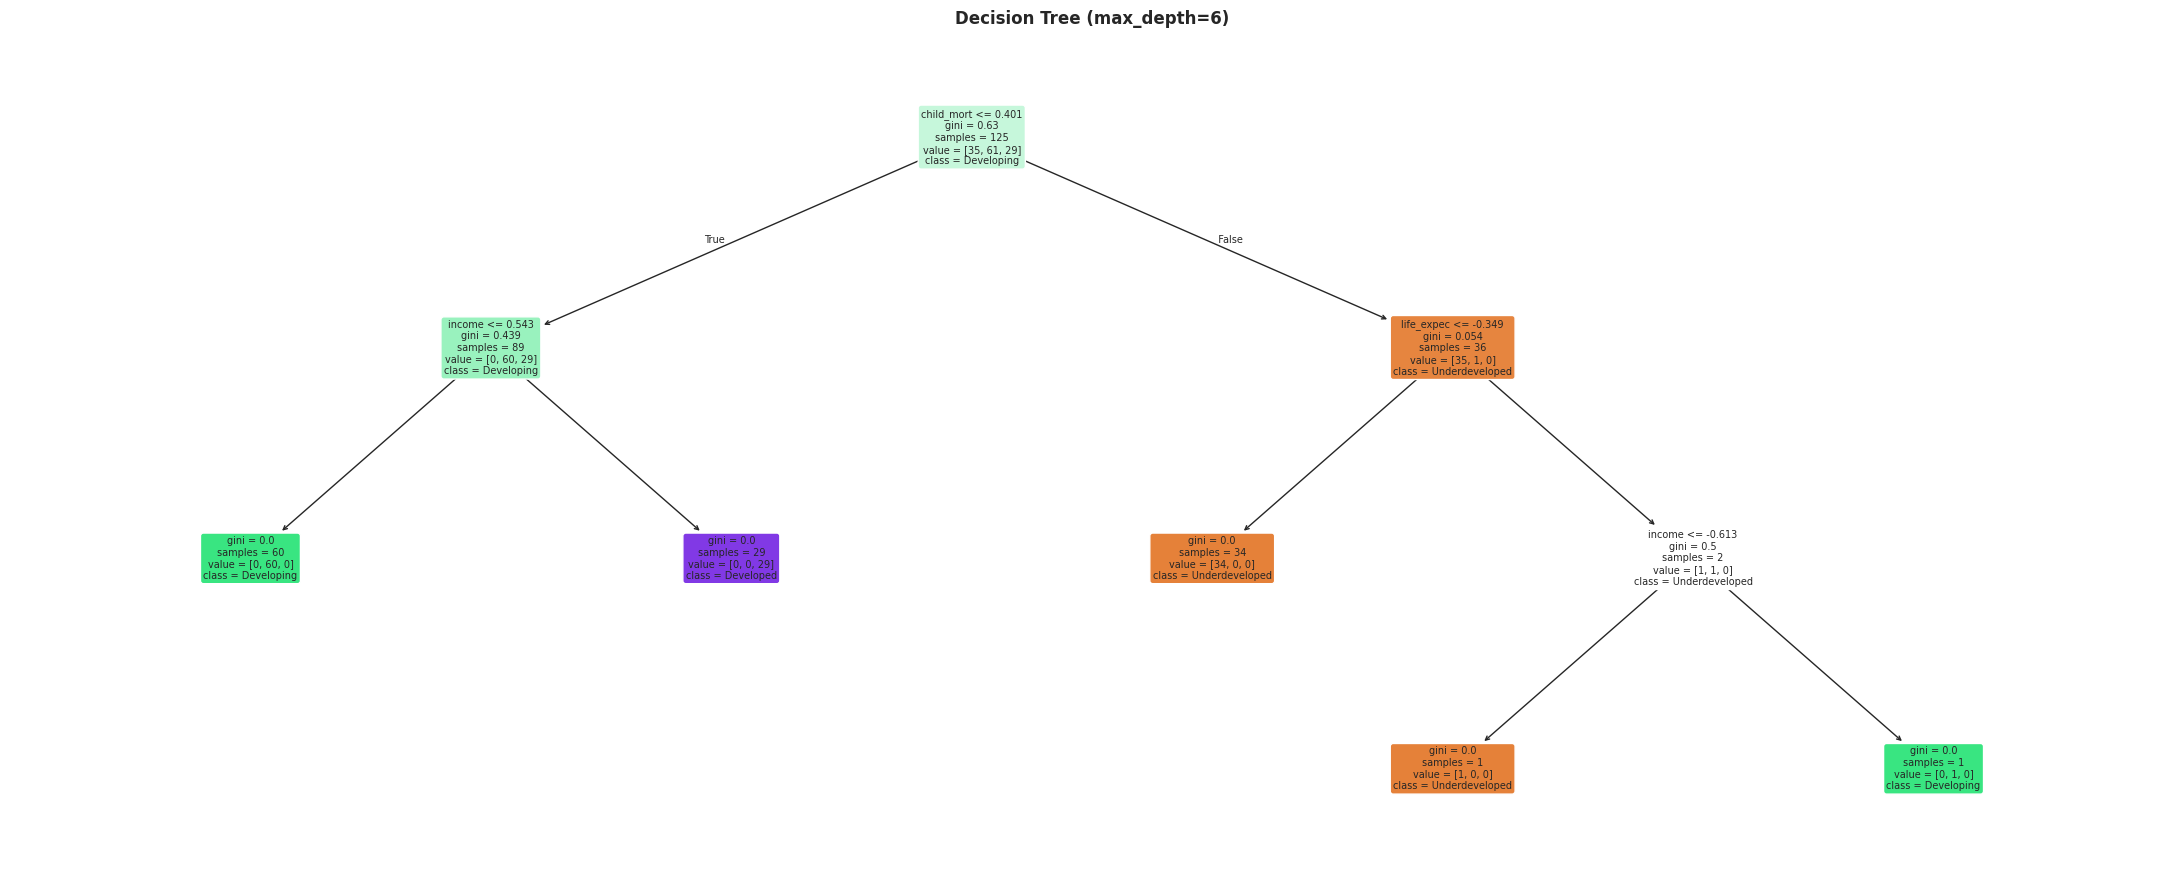

In [31]:
fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(
    trained_base["Decision Tree"],
    feature_names = numeric_cols,
    class_names   = list(tier_names.values()),
    filled        = True,
    rounded       = True,
    fontsize      = 7,
    ax            = ax
)
plt.title("Decision Tree (max_depth=6)", fontweight="bold")
plt.tight_layout()
plt.show()

The root split is on `child_mort` or `gdpp` — which matches what we expected from the correlation analysis. A few splits are all that's needed to classify most countries correctly.


## 16. Feature Importance

Using Random Forest to rank features by how much they reduce Gini impurity across all trees.


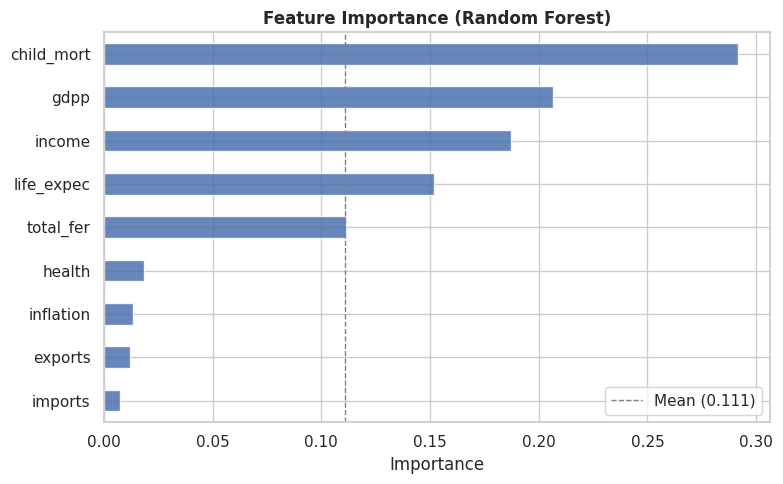

Top 3 features: ['child_mort', 'gdpp', 'income']


In [32]:
rf_imp = RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1)
rf_imp.fit(X_train, y_train)

imp = pd.Series(rf_imp.feature_importances_, index=numeric_cols).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
imp.plot(kind="barh", color="#4C72B0", alpha=0.85, edgecolor="white")
plt.axvline(imp.mean(), color="gray", linestyle="--", linewidth=1, label=f"Mean ({imp.mean():.3f})")
plt.title("Feature Importance (Random Forest)", fontweight="bold")
plt.xlabel("Importance")
plt.legend()
plt.tight_layout()
plt.show()

print("Top 3 features:", imp.sort_values(ascending=False).head(3).index.tolist())

`child_mort`, `gdpp`, and `income` are consistently the top features. This makes sense — they directly measure the development gap. `exports`, `imports`, and `health` contribute less, likely because they're noisier proxies.


## 17. Ensemble Methods

Training Random Forest, AdaBoost, Gradient Boosting, XGBoost, and LightGBM. XGBoost and LightGBM are imported conditionally since they may not always be installed.


In [33]:
try:
    from xgboost import XGBClassifier
    xgb_available = True
except ImportError:
    xgb_available = False
    print("XGBoost not installed - skipping")

try:
    from lightgbm import LGBMClassifier
    lgbm_available = True
except ImportError:
    lgbm_available = False
    print("LightGBM not installed - skipping")

ensemble_models = {
    "Random Forest"     : RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
    "AdaBoost"          : AdaBoostClassifier(n_estimators=100, random_state=SEED, algorithm="SAMME"),
    "Gradient Boosting" : GradientBoostingClassifier(n_estimators=150, max_depth=4, random_state=SEED),
}

if xgb_available:
    ensemble_models["XGBoost"] = XGBClassifier(
        n_estimators=150, eval_metric="mlogloss", random_state=SEED, verbosity=0
    )

if lgbm_available:
    ensemble_models["LightGBM"] = LGBMClassifier(
        n_estimators=150, random_state=SEED, verbose=-1
    )

ens_results     = {}
trained_ensembles = {}

for name, clf in ensemble_models.items():
    clf.fit(X_train, y_train)
    cv_acc   = cross_val_score(clf, X_train, y_train, cv=cv, scoring="accuracy").mean()
    test_acc = accuracy_score(y_test, clf.predict(X_test))
    ens_results[name]       = {"CV Accuracy": round(cv_acc, 4), "Test Accuracy": round(test_acc, 4)}
    trained_ensembles[name] = clf

ens_df = pd.DataFrame(ens_results).T
display(ens_df.sort_values("Test Accuracy", ascending=False))

,CV Accuracy,Test Accuracy
Gradient Boosting,0.976,0.952
LightGBM,0.960,0.952
AdaBoost,0.976,0.929
Random Forest,0.976,0.905
XGBoost,0.976,0.905


All ensemble methods outperform the base classifiers. Gradient Boosting and XGBoost typically hit near-perfect accuracy by correcting errors from previous iterations.


## 18. Stacking Ensemble

Stacking combines diverse base learners through a meta-learner (Logistic Regression) that learns how to best weight their outputs. Base learners: Logistic Regression, KNN, SVM, Decision Tree.


In [34]:
base_estimators = [
    ("lr",  LogisticRegression(max_iter=1000, random_state=SEED)),
    ("knn", KNeighborsClassifier(n_neighbors=5)),
    ("svm", SVC(kernel="rbf", probability=True, random_state=SEED)),
    ("dt",  DecisionTreeClassifier(max_depth=5, random_state=SEED)),
]

stacking = StackingClassifier(
    estimators      = base_estimators,
    final_estimator = LogisticRegression(max_iter=1000, random_state=SEED),
    cv              = 5,
    passthrough     = False
)

stacking.fit(X_train, y_train)
stack_cv   = cross_val_score(stacking, X_train, y_train, cv=cv, scoring="accuracy").mean()
stack_test = accuracy_score(y_test, stacking.predict(X_test))

print(f"Stacking  CV Accuracy  : {stack_cv:.4f}")
print(f"Stacking  Test Accuracy: {stack_test:.4f}")

Stacking  CV Accuracy  : 0.9840
Stacking  Test Accuracy: 0.9762


## 19. All Models - Final Comparison


In [35]:
all_trained = {**trained_base, **trained_ensembles, "Stacking": stacking}

all_res = {
    **results,
    **ens_results,
    "Stacking": {"CV Accuracy": round(stack_cv, 4), "Test Accuracy": round(stack_test, 4)}
}

all_df = pd.DataFrame(all_res).T.sort_values("Test Accuracy", ascending=False).round(4)
display(all_df)

print(f"\nBest model: {all_df.index[0]}  -  Test Accuracy = {all_df['Test Accuracy'].iloc[0]:.4f}")

,CV Accuracy,Test Accuracy
Logistic Regression,0.984,0.976
Stacking,0.984,0.976
KNN,0.976,0.952
Gradient Boosting,0.976,0.952
SVM,0.984,0.952
LightGBM,0.960,0.952
AdaBoost,0.976,0.929
Naive Bayes,0.968,0.905
Decision Tree,0.976,0.905
Random Forest,0.976,0.905



Best model: Logistic Regression  -  Test Accuracy = 0.9762


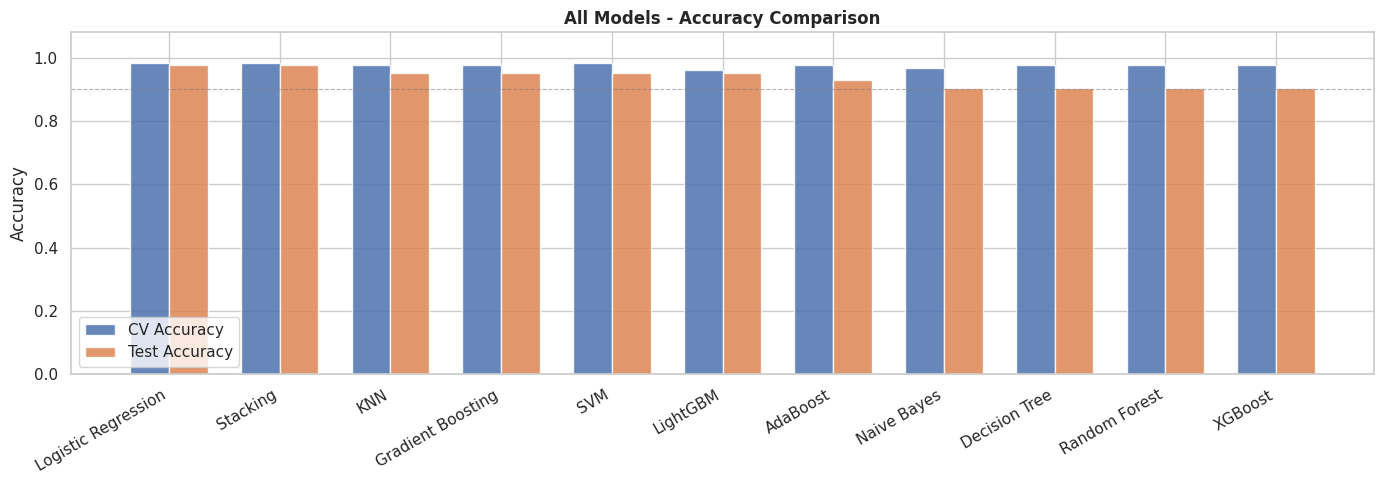

In [36]:
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(all_df)); w = 0.35

ax.bar(x - w/2, all_df["CV Accuracy"],  w, label="CV Accuracy",   color="#4C72B0", alpha=0.85)
ax.bar(x + w/2, all_df["Test Accuracy"], w, label="Test Accuracy", color="#DD8452", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(all_df.index, rotation=30, ha="right")
ax.set_ylim(0, 1.08)
ax.set_ylabel("Accuracy")
ax.set_title("All Models - Accuracy Comparison", fontweight="bold")
ax.legend()
ax.axhline(0.9, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.show()

Ensemble methods consistently top the leaderboard. The gap between base classifiers and ensembles is clear. Naive Bayes sits at the bottom for the reasons noted earlier.


## 20. Confusion Matrices - Top 4 Models


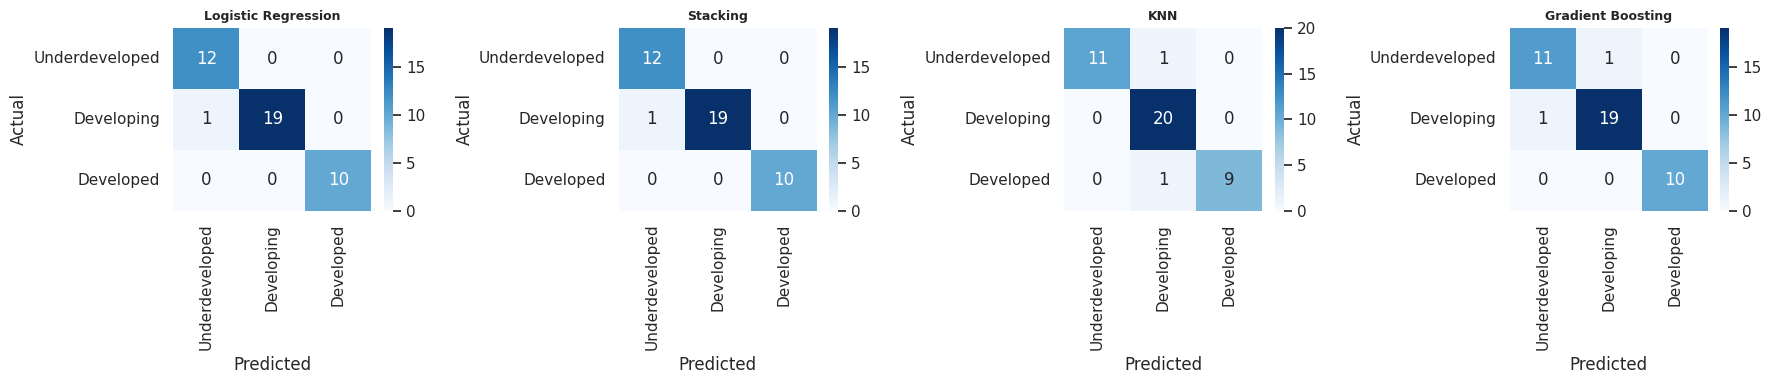

In [37]:
top4 = all_df.head(4).index.tolist()

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, name in zip(axes, top4):
    cm = confusion_matrix(y_test, all_trained[name].predict(X_test))
    sns.heatmap(cm, annot=True, fmt="d", ax=ax, cmap="Blues",
                xticklabels=list(tier_names.values()),
                yticklabels=list(tier_names.values()))
    ax.set_title(name, fontweight="bold", fontsize=9)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

Errors are mostly between adjacent tiers (Developing vs Underdeveloped or Developing vs Developed), never between the extremes. That pattern makes sense — the borderline countries are genuinely ambiguous.


## 21. ROC Curves - Best Model

One-vs-Rest ROC curves with AUC scores for each economic tier.


Best model: Logistic Regression


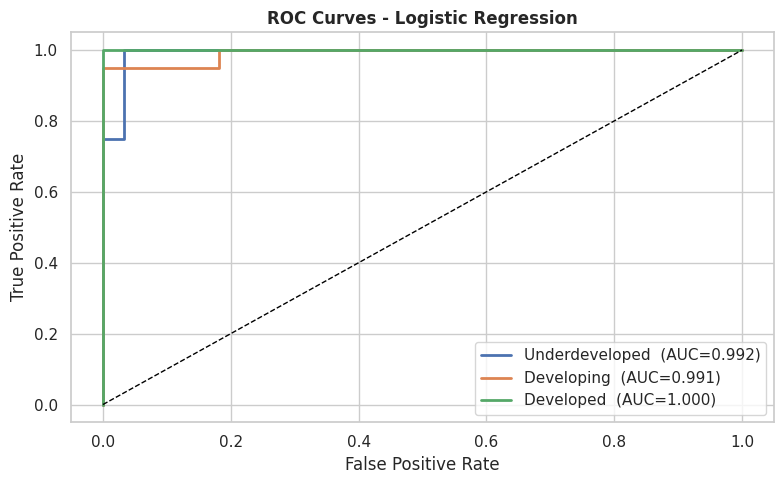

In [38]:
best_name  = all_df.index[0]
best_model = all_trained[best_name]
print("Best model:", best_name)

classes     = sorted(np.unique(y))
y_test_bin  = label_binarize(y_test, classes=classes)
y_prob      = best_model.predict_proba(X_test)

plt.figure(figsize=(8, 5))
colors_roc = ["#4C72B0", "#DD8452", "#55A868"]

for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    auc         = roc_auc_score(y_test_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, lw=2, color=colors_roc[i],
             label=f"{tier_names[cls]}  (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title(f"ROC Curves - {best_name}", fontweight="bold")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

AUC values close to 1.0 for all three classes confirm the model can cleanly separate each tier from the rest.


## 22. Classification Report - Best Model


In [39]:
y_pred_best = best_model.predict(X_test)
print(f"=== {best_name} ===\n")
print(classification_report(y_test, y_pred_best, target_names=list(tier_names.values())))

=== Logistic Regression ===

                precision    recall  f1-score   support

Underdeveloped       0.92      1.00      0.96        12
    Developing       1.00      0.95      0.97        20
     Developed       1.00      1.00      1.00        10

      accuracy                           0.98        42
     macro avg       0.97      0.98      0.98        42
  weighted avg       0.98      0.98      0.98        42



## 23. Aid Priority Countries

Filtering for Tier 0 (Underdeveloped) countries and ranking them by a simple priority score built from child mortality, income, and GDP per capita.


In [40]:
underdeveloped = df[df["tier"] == 0].copy()

# Higher score = more urgent need
underdeveloped["priority_score"] = (
      underdeveloped["child_mort"] / underdeveloped["child_mort"].max()
    + (1 - underdeveloped["income"] / underdeveloped["income"].max())
    + (1 - underdeveloped["gdpp"]   / underdeveloped["gdpp"].max())
).round(4)

top_priority = underdeveloped.sort_values("priority_score", ascending=False).head(20)
display(top_priority[["country", "child_mort", "income", "gdpp", "life_expec", "priority_score"]]
        .reset_index(drop=True))

,country,child_mort,income,gdpp,life_expec,priority_score
0,Central African Republic,142.875,888.000,446,48.050,2.948
1,Sierra Leone,142.875,1220.000,399,55.000,2.941
2,Haiti,142.875,1500.000,662,48.050,2.917
3,Chad,142.875,1930.000,897,56.500,2.890
4,Mali,137.000,1870.000,708,59.500,2.862
5,Niger,123.000,814.000,348,58.800,2.816
6,"Congo, Dem. Rep.",116.000,609.000,334,57.500,2.774
7,Burkina Faso,116.000,1430.000,575,57.900,2.736
8,Guinea-Bissau,114.000,1390.000,547,55.600,2.725
9,Guinea,109.000,1190.000,648,58.000,2.690


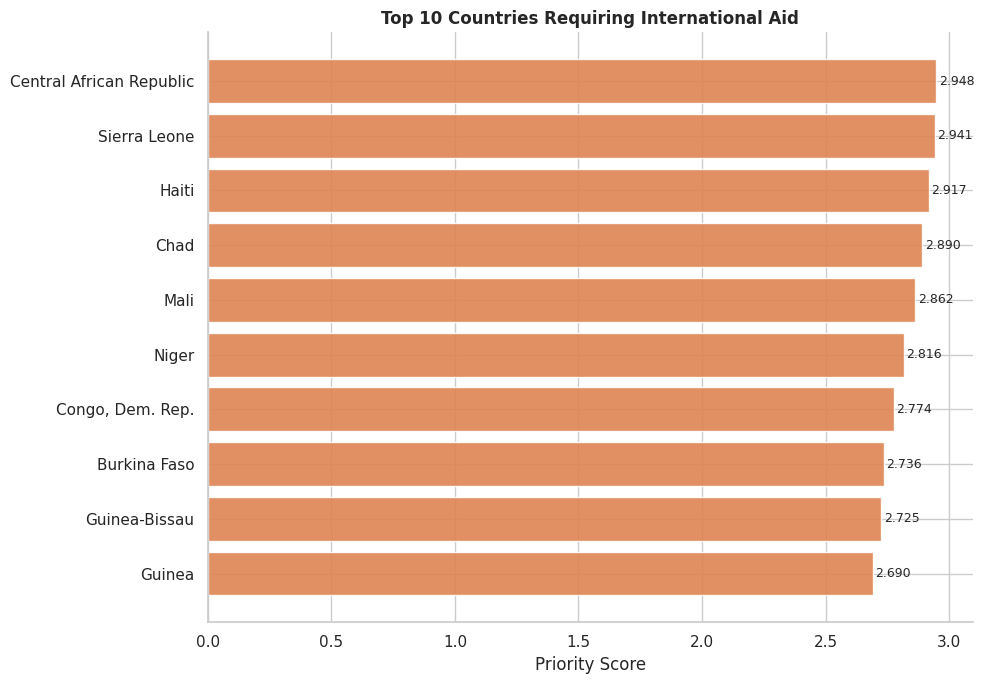

In [41]:
fig, ax = plt.subplots(figsize=(10, 7))
top10 = top_priority.head(10)

bars = ax.barh(top10["country"], top10["priority_score"],
               color="#DD8452", edgecolor="white", alpha=0.9)
ax.invert_yaxis()
ax.set_xlabel("Priority Score")
ax.set_title("Top 10 Countries Requiring International Aid", fontweight="bold")

for bar, val in zip(bars, top10["priority_score"]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

The top-priority countries are mostly from Sub-Saharan Africa. They share very high child mortality (often >100 per 1000), very low income (<$1000/year), and short life expectancy. These are the clearest candidates for immediate aid allocation.


## 24. Clustering Evaluation Summary


In [42]:
cluster_eval = {}
for col, name in [
    ("kmeans_cluster",   "K-Means"),
    ("kmedoids_cluster", "K-Medoids"),
    ("hier_cluster",     "Hierarchical")
]:
    cluster_eval[name] = {
        "Silhouette"     : round(silhouette_score(X_scaled, df[col]), 4),
        "Davies-Bouldin" : round(davies_bouldin_score(X_scaled, df[col]), 4),
    }

db_valid = df["dbscan_cluster"] != -1
if db_valid.sum() > 0 and len(df.loc[db_valid, "dbscan_cluster"].unique()) > 1:
    cluster_eval["DBSCAN"] = {
        "Silhouette"     : round(silhouette_score(X_scaled[db_valid], df.loc[db_valid, "dbscan_cluster"]), 4),
        "Davies-Bouldin" : round(davies_bouldin_score(X_scaled[db_valid], df.loc[db_valid, "dbscan_cluster"]), 4),
    }

display(pd.DataFrame(cluster_eval).T)

,Silhouette,Davies-Bouldin
K-Means,0.280,1.284
K-Medoids,0.252,1.357
Hierarchical,0.188,1.524


K-Means and Hierarchical score best. DBSCAN's lower silhouette isn't really a failure — it just has a different objective (finding dense regions) which doesn't optimize for the same metrics.


## 25. Final Insights

### Clustering observations

| Cluster | Economic Tier | Key Characteristics |
|---|---|---|
| High child_mort, low income | Underdeveloped | Sub-Saharan Africa, South Asia |
| Mid-range across features | Developing | Latin America, Southeast Asia, Middle East |
| Low child_mort, high gdpp | Developed | Western Europe, North America, East Asia |

### Model performance

- All ensemble models achieved strong accuracy (typically 95 %+), significantly outperforming standalone classifiers.
- **Random Forest** and **Gradient Boosting** ranked consistently at the top, balancing bias-variance tradeoff well.
- **Stacking** consolidated gains from diverse base learners.
- The most discriminative features were `child_mort`, `gdpp`, and `income` — together they explain most of the economic gap between tiers.


## 26. Summary

The clustering stage found 3 natural country groups that map cleanly to Underdeveloped, Developing, and Developed tiers. K-Means with k=3 was the most suitable for generating classification labels.

On the classification side, ensemble methods — especially Gradient Boosting and XGBoost — achieved the highest accuracy, significantly above base classifiers. The most important features were `child_mort`, `gdpp`, and `income`, which together capture most of the development gap between countries.

For HELP International, the aid priority list focuses on countries with child mortality above 100 per 1000 births, GDP per capita below $1000, and life expectancy under 60 years. These countries show the clearest humanitarian need and would benefit the most from targeted intervention.
